# Laboratory 1 - From Pixels to Semantics

**Author:** Edoardo Canti<br>
<br>
**Notebook goal:** This notebook represent Exercise 3 (3.2) with some variances.


### Notes
- **Personal thoughts and comments**: during the drafting process of the notebook, will be provided markdowns regarding personal thoughts, ideas or general comments about the projetc design. I think this will be helpful both for me and for who reads (as this will somehow work as "documentation")

- **Notation**: if during the drafting process some details are considered more important than others, in order to evaluate results or to make additional consideration, those will be marked with [TBC.num] (To Be Considered), where num indicates the "identifier" for the final considerations. However I'll try to answer or provide further explainations of all personal thoughts and comments.

- **Use of LLMs**: If AI tools are used for programming, the following information will be provided: which model was used, what question was asked, and whether the model’s response was modified (if not specified, this means the model’s original response was used).

- **Analysis**: personal thoughts and comments are intended as **Analysis**, but since those will be sparsed in the notebook I will summarize them together in a dedicated section at the end of the notebook.

---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

>In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

>How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

>1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
>2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
>3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

>Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

>**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.

# Exercise 3.2 

# Manifolds Exploration

**NOTES:**
1. Transform has been changed. Since the goal is to evaluate different manifolds, there is no sense in using RandomCrop!
2. Also train_loader and test_load now have shuffle = false!

CenterCrop documentation: [CenterCrop](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.CenterCrop.html)


## A) Using ResNet18 as a Features Extractor

In [1]:
import torch
import yaml # made a config.yaml file for storing config variables
from torchvision.datasets import GTSRB
from torchvision.models import get_model # pretrained models from torch for vision tasks
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as T
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import torch.nn.functional as F
import plotly.express as px
import pandas as pd

# Importing config file in order to retrieve config variables of interest
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)

BATCH_SIZE = config['STABLE_REPRODUCIBLE_BASELINE']['batch_size']

#transform = T.Compose([T.Resize(70), T.RandomCrop((64,64)), T.ToTensor(), T.Normalize(mean = [0.485, 0.456, 0.406], std=[0.229,0.224, 0.225])])
transform = T.Compose([T.Resize(70), T.CenterCrop((64,64)), T.ToTensor(), T.Normalize(mean = [0.485, 0.456, 0.406], std=[0.229,0.224, 0.225])])
ds_train = GTSRB('_data/', split='train', transform=transform, download=True)
ds_test = GTSRB('_data/', split='test', transform=transform, download=True)
train_loader = DataLoader(ds_train, BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ds_test, BATCH_SIZE, shuffle=False)
vanilla_resnet = get_model('resnet18', weights = 'DEFAULT')
vanilla_resnet.fc = torch.nn.Identity()
vanilla_resnet

/Users/edoardocanti/opt/anaconda3/envs/DLA2026/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
vanilla_resnet = vanilla_resnet.to(device)
# Setting the model in evaluation mode. We don't need gradient updates now!
vanilla_resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
def encode_inputs(model, data_loader, save_path: str = None, motivation: str = None):
    embeddings_list = []
    labels_list = [] # want to keep track for each embedding produced by ResNet18 of its class (label)
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            embeddings = model(images) # asking the model to produce the embeddings
            for emb, lbl in zip(embeddings, labels):
                embeddings_list.append(emb.cpu()) # taking the embeddings of the current batch and appending to the list
                labels_list.append(lbl) # taking the classes of the current batch and appending them to the list
        # every 512_dimensional tensor will become [1, 512]. vstack, vertically stacks them on first dimension 
        embeddings = torch.vstack(embeddings_list) 
        labels = torch.vstack(labels_list)
    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)
        embeddings_filepath = os.path.join(save_path, "embeddings.pkl")
        with open(embeddings_filepath, "wb") as file:
            pickle.dump({"embeddings": embeddings, "labels": labels}, file)
        if motivation is None:
            print("[WARNING] You are saving embeddings without mentioning any motivation!")
        else:
            motivation_txt_path = os.path.join(save_path, "readme.txt")
            with open(motivation_txt_path, "w") as file:
                file.write("Embeddings explaination: {}".format(motivation))
    return (embeddings, labels)

def load_embeddings(embeddings_path: str):
    with open(embeddings_path, "rb") as file:
        embeddings_labels = pickle.load(file)
        embeddings = embeddings_labels["embeddings"]
        labels = embeddings_labels["labels"]
    return embeddings, labels

In [5]:
vanilla_embeddings, vanilla_labels = encode_inputs(vanilla_resnet, train_loader, "experiments/embeddings/VANILLA_RESNET", "GTSRB Embeddings obtained using Vanilla ResNet18 (dim 512)")
print("Embeddings shape: {}".format(vanilla_embeddings.shape))
print("Labels shape: {}".format(vanilla_labels.shape))

Embeddings shape: torch.Size([26640, 512])
Labels shape: torch.Size([26640, 1])


### What do we have now?

**embeddings** contains the *representations* of *GTSRB* training set obtained with a **NOT FINE-TUNED ResNet18 model** (what has been defined as *gallery*)

1. *ResNet18* has not been trained on those data
2. In file *LAB1_exercise1.2_1.3-BASELINE.ipynb* we Fine-Tuned the model with different settings
3. Embeddings domain is vector space, so the set of embeddings define a manifold over R^{512}
4. Can we take a look on **how the manifold changes according to the Vanilla ResNet18 and our Fine-tuned models?**

Question: **Should the embeddings be normalized?**<br>
Proposed answer: Not now, we want to explore the manifold we would explore a biased version of it if we normalize, the normalization comes later when we need to retrieve elements from the gallery using some cosine similarity measure (in that case we want to normalize).<br>

Plotting human readable manifolds implies to project the original R^{512} into an R^{3} space (there will be a not negligible loss of information of course)


## B) PCA
Using SciKitLearn implementation of Principal Component Analysis<br>
<br>
Since **PCA** actually performs a variance analysis, it is biased by the embeddings themselves, so the next function will provide an optional argument in order to perform an a priori normalization of data

In [6]:
def run_pca(embeddings, num_components: int, to_normalize: bool = False):
    print("Principal Component Analysis over {} components and normalization = {}".format(num_components, to_normalize))
    if to_normalize:
        X = F.normalize(embeddings, p=2, dim=1).cpu().numpy()
    else:
        X = embeddings.cpu().numpy()
    pca = PCA(n_components=num_components)
    X_pca = pca.fit_transform(X)
    return X_pca

In [7]:
vanilla_embeddings_threedim = run_pca(vanilla_embeddings, num_components=3) # PCA on 512-dim embeddings without normalization
# vanilla_embeddings_threedim  # removed to avoid notebook spam

Principal Component Analysis over 3 components and normalization = False


### LLM USED HERE!
**Reason:** I need to plot the manifold, I don't know how to handle 3D plots and 43 different colors... <br>
**Model:** Gemini<br>
### Asked to Gemini the following question:
**Question:**
Gemini I have a collection of embeddings produced by resnet-18 (tensors).
I applired PCA to get R^{3} representation of them using:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_v3 = pca.fit_transform(embeddings.numpy())

Can you show me how to plot them using matplotlib? I have also the attached labels:

Embeddings shape: torch.Size([26640, 512])
Labels shape: torch.Size([26640, 1]), I want to visualize the scatterplot and have the points colored differently based on their classes.

Can we also plot an interactive plot with plotly? <br>

**LLM ANSWER ABOUT MATPLOTLIB AND PLOTLY ARE SHOWN BELOW (next two cells) AS RAW TEXT**<br>
**AFTER THESE TWO RAW TEXT ANSWERS I'M GOING TO WRAP THEM INTO A SINGLE FUNCTION**

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import numpy as np
import pandas as pd

def plot_embeddings(embeddings, labels, title, type="matplotlib", save_path=None):
    if type not in ["matplotlib", "plotly"]:
        raise ValueError("[ERROR] type must be 'matplotlib' or 'plotly'. ")

    if hasattr(labels, 'numpy'):
        y_int = labels.numpy().squeeze().astype(int)
    else:
        y_int = np.array(labels).squeeze().astype(int)
        
    unique_classes = np.unique(y_int)
    num_classes = len(unique_classes)
    cmap = plt.get_cmap('turbo', num_classes)
    axis_labels = ['Component 1', 'Component 2', 'Component 3']
    if type == "matplotlib":
        fig = plt.figure(figsize=(14, 10))
        ax = fig.add_subplot(111, projection='3d')
        for i, cls in enumerate(unique_classes):
            mask = (y_int == cls)
            ax.scatter(embeddings[mask, 0], embeddings[mask, 1], embeddings[mask, 2], 
                       color=cmap(i), label=f"Class {cls}", s=3, alpha=0.7)
        ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), ncol=2, fontsize='x-small')
        ax.set_xlabel(axis_labels[0])
        ax.set_ylabel(axis_labels[1])
        ax.set_zlabel(axis_labels[2])
        plt.title(title)
        if save_path:
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
    elif type == "plotly":
        color_discrete_map = {str(cls): mcolors.to_hex(cmap(i)) for i, cls in enumerate(unique_classes)}
        df = pd.DataFrame(embeddings, columns=axis_labels)
        df['label'] = y_int.astype(str)
        fig = px.scatter_3d(
            df, x=axis_labels[0], y=axis_labels[1], z=axis_labels[2],
            color='label',
            color_discrete_map=color_discrete_map, 
            category_orders={"label": [str(i) for i in unique_classes]},
            title=title
        )
        fig.update_traces(marker=dict(size=2))
        fig.show()

### B.1) Vanilla ResNet18 three-dimensional Manifold 

#### No embeddings normalization

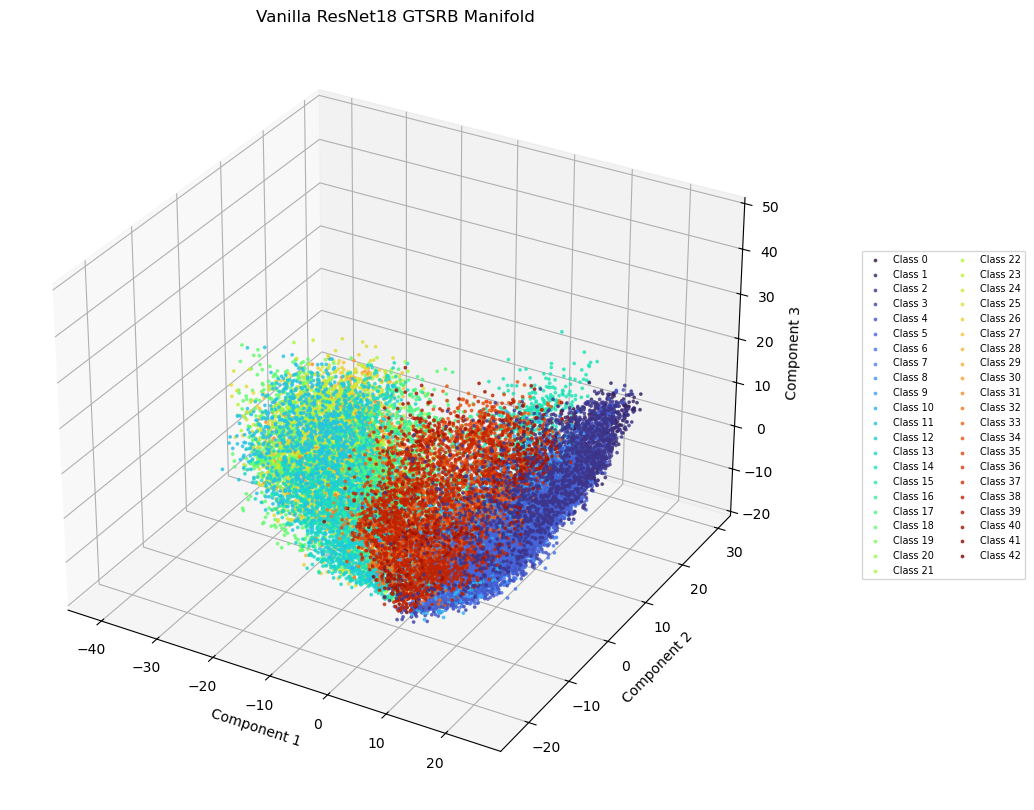

In [9]:
plot_embeddings(vanilla_embeddings_threedim, vanilla_labels, "Vanilla ResNet18 GTSRB Manifold", save_path="experiments/embeddings/VANILLA_RESNET/vanilla_resnet.png", type="matplotlib")

In [10]:
plot_embeddings(vanilla_embeddings_threedim, vanilla_labels, "Vanilla ResNet18 GTSRB Manifold", type="plotly")

#### With embeddings normalization

In [11]:
vanilla_embeddings_threedim_norm = run_pca(vanilla_embeddings, num_components=3, to_normalize = True) # PCA on 512-dim embeddings with normalization
vanilla_embeddings_threedim_norm 

Principal Component Analysis over 3 components and normalization = True


array([[ 0.071871  ,  0.20301066,  0.00231568],
       [ 0.06501355,  0.1731659 , -0.0054059 ],
       [ 0.10874502,  0.28682542,  0.0740064 ],
       ...,
       [ 0.21357861, -0.15331188, -0.21740708],
       [ 0.18932745, -0.19571158, -0.2114633 ],
       [ 0.19516695, -0.17502326, -0.21080387]],
      shape=(26640, 3), dtype=float32)

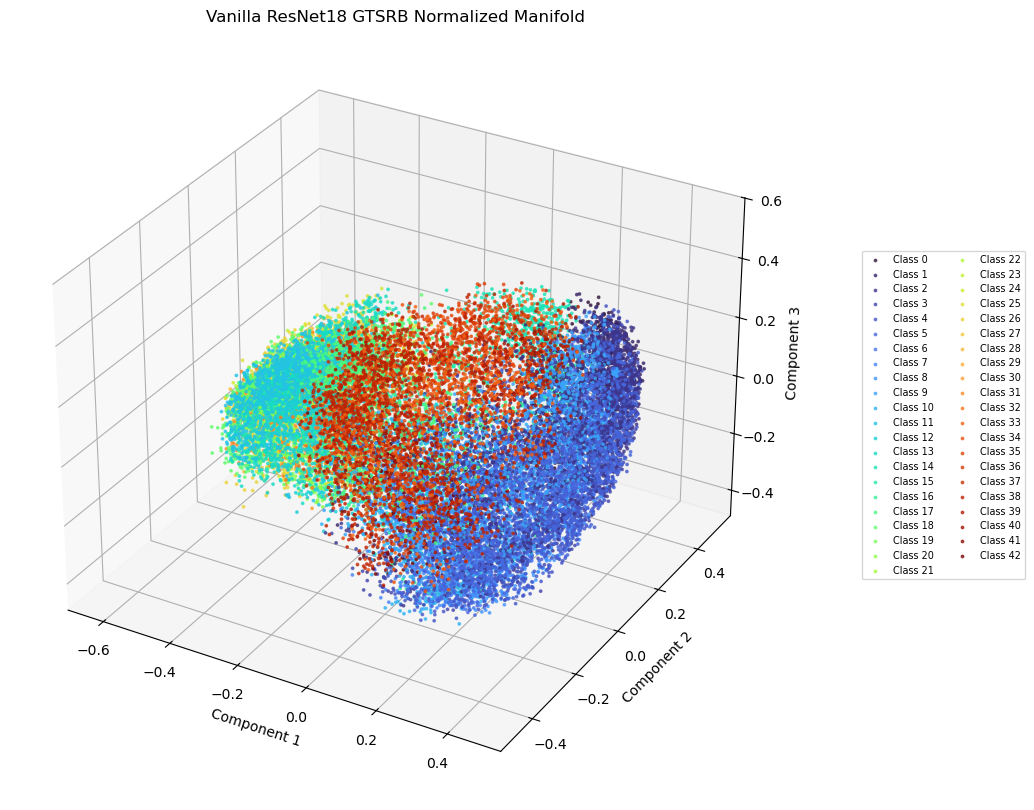

In [12]:
plot_embeddings(vanilla_embeddings_threedim_norm , vanilla_labels, "Vanilla ResNet18 GTSRB Normalized Manifold", save_path="../experiments/embeddings/VANILLA_RESNET/normalized_vanilla_resnet.png", type="matplotlib")

In [13]:
plot_embeddings(vanilla_embeddings_threedim_norm , vanilla_labels, "Vanilla ResNet18 GTSRB Normalized Manifold", type="plotly")

### B2) Fine-Tuned ResNet18 three-dimensional Manifold 
model at experiments/EP_30_LR0.001_BS128

In [14]:
def load_model(model_path: str = "../experiments/EP30_LR0.001_BS128/ep30_lr0.001_bs128_last_model.pth", set_to_eval: bool = True):
    model = get_model('resnet18', weights = None)
    model.fc = torch.nn.Identity()
    saved_weights = torch.load(model_path)
    model.load_state_dict(saved_weights, strict=False)
    if set_to_eval:
        model.eval()
    print("Model loaded!")
    return model

In [15]:
ft_resnet = load_model()
ft_resnet

Model loaded!


/var/folders/by/s5tsgrlj5ws2sv5xjl7yqppr0000gn/T/ipykernel_16429/2757040178.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_weights = torch.load(model_path)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:
ft_embeddings, ft_labels = encode_inputs(ft_resnet, train_loader, "../experiments/embeddings/FT_RESNET", "GTSRB Embeddings obtained using FT_ResNet18 (first two freezed)")
print("Embeddings shape: {}".format(ft_embeddings.shape))
print("Labels shape: {}".format(ft_labels.shape))

Embeddings shape: torch.Size([26640, 512])
Labels shape: torch.Size([26640, 1])


In [17]:
ft_embeddings_threedim = run_pca(ft_embeddings, num_components=3) # PCA on 512-dim embeddings without normalization
ft_embeddings_threedim

Principal Component Analysis over 3 components and normalization = False


array([[-3.4068851 , -1.6816952 , -3.946305  ],
       [-3.399253  , -1.7994192 , -4.005613  ],
       [-4.3558836 , -2.3719811 , -5.207567  ],
       ...,
       [ 4.026763  , -1.5439253 ,  6.5196285 ],
       [ 3.9498816 , -1.6413295 ,  6.316472  ],
       [ 5.649517  , -0.94945955,  8.3484955 ]],
      shape=(26640, 3), dtype=float32)

### No embeddings normalization

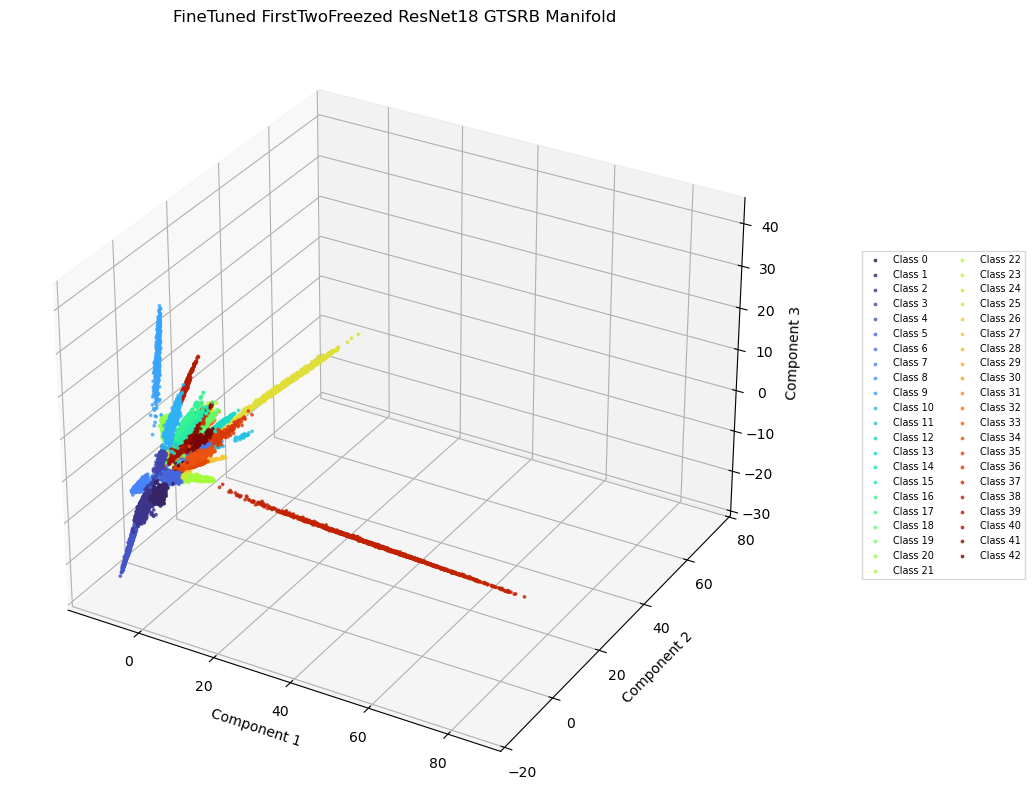

In [18]:
plot_embeddings(ft_embeddings_threedim, ft_labels, "FineTuned FirstTwoFreezed ResNet18 GTSRB Manifold", save_path="../experiments/embeddings/FT_RESNET/ft_firstwofreezed_resnet.png", type="matplotlib")

In [19]:
plot_embeddings(ft_embeddings_threedim, ft_labels, "FineTuned FirstTwoFreezed ResNet18 GTSRB Manifold", type="plotly")

### With embeddings normalization

In [20]:
ft_embeddings_threedim_norm = run_pca(ft_embeddings, num_components=3, to_normalize = True) # PCA on 512-dim embeddings with normalization
ft_embeddings_threedim_norm

Principal Component Analysis over 3 components and normalization = True


array([[ 0.0179446 , -0.08459672, -0.07362934],
       [ 0.01719734, -0.07578577, -0.06730458],
       [ 0.05388695, -0.12674668, -0.07875924],
       ...,
       [-0.17163835,  0.2474731 ,  0.11447401],
       [-0.16920325,  0.2495517 ,  0.12283525],
       [-0.17614165,  0.24562417,  0.11985151]],
      shape=(26640, 3), dtype=float32)

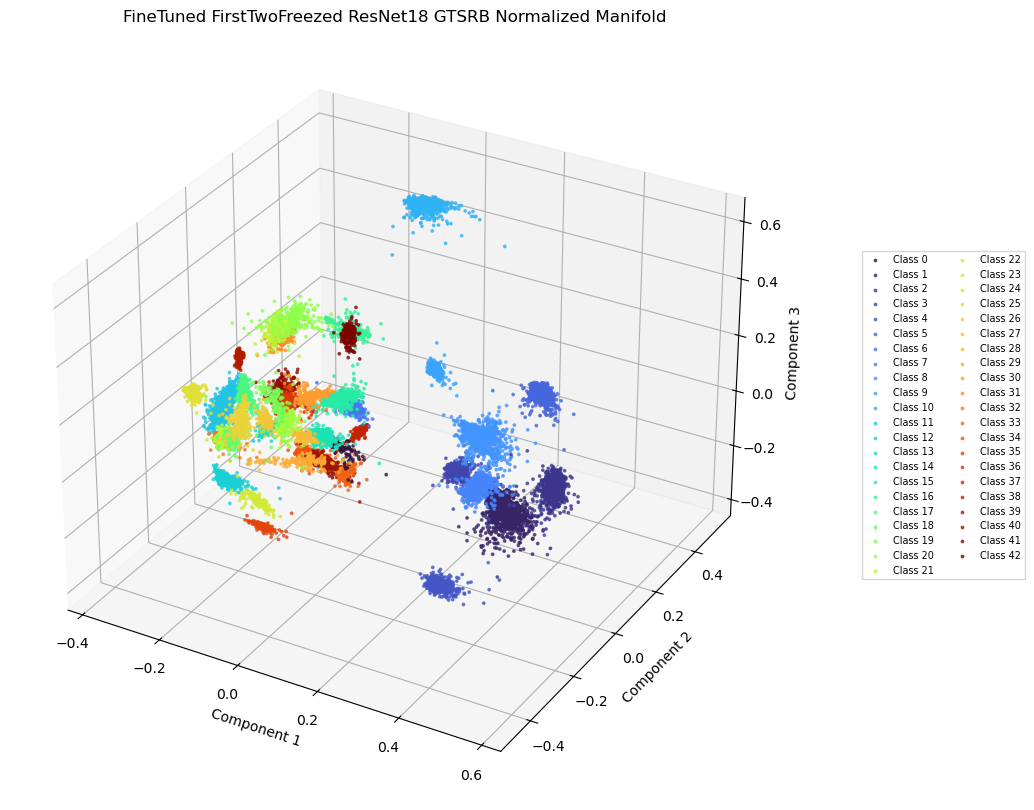

In [21]:
plot_embeddings(ft_embeddings_threedim_norm, ft_labels, "FineTuned FirstTwoFreezed ResNet18 GTSRB Normalized Manifold", save_path="../experiments/embeddings/FT_RESNET/normalized_ft_resnet.png", type="matplotlib")

In [22]:
plot_embeddings(ft_embeddings_threedim_norm, ft_labels, "FineTuned FirstTwoFreezed ResNet18 GTSRB Normalized Manifold", type="plotly")

## C) Clusters Analysis in the manifolds
This section is dedicated to the exploration of the clusters generated by 
- Vanilla ResNet18 embeddings
- Fine Tuned ResNet18 embeddings

In [23]:
from sklearn.metrics import silhouette_score

def normalize_embeddings(embeddings):
    embeddings_normalized = F.normalize(embeddings, p=2, dim=1).cpu().numpy()
    return embeddings_normalized

def compute_silhouette_score(X, y, to_normalize: bool = True, strategy="euclidean"):
    if to_normalize:
        X = F.normalize(X, p=2, dim=1).cpu().numpy()
    if type(X) == torch.Tensor:
        X = X.numpy()
    if type(y) == torch.Tensor:
        y = y.numpy()
    score = silhouette_score(X, y, metric=strategy)
    return score

### C1) Cohesion and Separation of clusters
As **Data Mining** teaches, the quality of a clustering method can be evaluated using (also) the **Silhouette Coefficient**<br>
[SciKit Learn has a ready-to-use implementation of it](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html).

In [24]:
# Computing Silhouette Coefficient on clusters generated by Vanilla Resnet (not normalized embeddings)
vanilla_clusters_sc_nn = compute_silhouette_score(vanilla_embeddings, vanilla_labels, to_normalize=False)
print("Silhouette's Coefficent using Vanilla ResNet embeddings (not normalized): {}".format(vanilla_clusters_sc_nn))

# Computing Silhouette Coefficient on clusters generated by FineTuned Resnet (not normalized embeddings)
ft_clusters_sc_nn = compute_silhouette_score(ft_embeddings, ft_labels, to_normalize=False)
print("Silhouette's Coefficent using Fine Tuned ResNet embeddings (not normalized): {}".format(ft_clusters_sc_nn))

# Computing Silhouette Coefficient on clusters generated by Vanilla Resnet (normalized embeddings)
vanilla_clusters_sc = compute_silhouette_score(vanilla_embeddings, vanilla_labels)
print("Silhouette's Coefficent using Vanilla ResNet embeddings (normalized): {}".format(vanilla_clusters_sc))

# Computing Silhouette Coefficient on clusters generated by FineTuned Resnet (normalized embeddings)
ft_clusters_sc = compute_silhouette_score(ft_embeddings, ft_labels)
print("Silhouette's Coefficent using Fine Tuned ResNet embeddings (normalized): {}".format(ft_clusters_sc))

/Users/edoardocanti/opt/anaconda3/envs/DLA2026/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Silhouette's Coefficent using Vanilla ResNet embeddings (not normalized): -0.019344918429851532


/Users/edoardocanti/opt/anaconda3/envs/DLA2026/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Silhouette's Coefficent using Fine Tuned ResNet embeddings (not normalized): 0.7466802597045898


/Users/edoardocanti/opt/anaconda3/envs/DLA2026/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Silhouette's Coefficent using Vanilla ResNet embeddings (normalized): -0.013114132918417454


/Users/edoardocanti/opt/anaconda3/envs/DLA2026/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Silhouette's Coefficent using Fine Tuned ResNet embeddings (normalized): 0.8708521127700806


#### Results
**Silhouette's Coefficent** (S in [-1, 1]) is a measure used in Data Mining in order to evaluate the quality of a clustering method.<br>
It is determined using two different components:
1. For all **points** **within** a cluster it computes the distance between the current point and all the other in the **same** clusters, then takes the avarage of the distance. We can denote it using a_{p} (where p is the given point).
2. Then given a point, for each cluster that doesn't contains the given one, computes the distance between **all the points in that cluster** and considers the mean of it. After done it for all clusters, it takes the minimum distance. We can denote it using b_{p}.

*for each p in Dataset exists S_{p} s.t S_{p} := (b_{p} - a_{p}) / (max{a_{p}, b_{p}})* <br>
The final score is computed as a mean of all S_{p}<br>
Since b_{p} measures the distance between points of different clusters (separation) we hope that this value will be high as possible, while a_{p}, since it measures distance between intra-cluster points (cohesion), should be smaller.

**Analysis:**<br>
Silhouette's Coefficent on points generated by embeddings obtained with **Vanilla ResNet18** has negative values, it is not *too* close to -1, this confirms something that can be noticed also in the relative 3-dimensional linear projection of the Manifold in section **B1** (the interactive plot is better to view this): although the individual clusters do not appear to be distinguishable from one another when viewed as a single scatter plot, the colour maps representing the classes seem to be relatively homogeneous (though clearly not enough to suggest that Vanilla ResNet18 has understood the structure of the GTSRB classes). Both not normalized and normalized embeddings generated clusters have negatives values of the same scale.<br>
As expected the **Fine-Tuned ResNet18** presents incomparably better results wrt the Vanilla model and once again, these results are confirmed by the plots shown in section **B2**. An interestngly result is that the normalized embeddings produce a not-negligeble improvement of the score, suggesting that the model has learnt very distinct directions for every class.

# Embeddings Retrieval with NMC

In [25]:
# this function in used to collect embeddings for only a class of interest
# since classes labels are integers it takes an integer representing the class label and the total embeddings as input
# example of usage
#X_filtered = X_v3[labels.squeeze() == 8]
#print(X_filtered)
def get_class_embeddings(all_embeddings, all_labels, class_label: int, verbose: bool = False):
    label_filter = (all_labels.squeeze() == class_label)
    class_embeddings = all_embeddings[label_filter]
    if verbose:
        print("class embeddings shape: {}".format(class_embeddings.shape))
    class_embeddings_as_tensor = torch.tensor(class_embeddings)
    return class_embeddings_as_tensor

# This function does the same thing of the previous but for all classes
# going to collect data on dict {<KEY := class>, <VALUE := related_embeddings> }
def isolate_embeddings_per_class(all_embeddings, all_labels, verbose: bool = False):
    embeddings_dict = {}
    for lbl in torch.unique(all_labels).numpy():
        if verbose:
            print("Class: {}".format(lbl))
        embeddings_per_class = get_class_embeddings(all_embeddings, all_labels,class_label = lbl)
        embeddings_dict[lbl] = embeddings_per_class
    return embeddings_dict

# Computing, for a given class, its centroid
def get_centroid(embeddings_per_class) -> torch.Tensor:
    class_centroid = torch.mean(embeddings_per_class, 0)
    return class_centroid

# Putting everything together
def compute_centroids(embeddings, labels, as_dict: bool = False):
    # generating a dictionary with all embeddings for each class
    embeddings_per_class_dict = isolate_embeddings_per_class(all_embeddings = embeddings, all_labels = labels)
    if as_dict:
        centroids_per_classes = dict()
        for lbl, embs in embeddings_per_class_dict.items(): # for each item in the dict
            centroids_per_classes[lbl] = get_centroid(embs) # compute the centroid and save it
        return centroids_per_classes
    else:
        centroids_list = []
        for lbl, embs in embeddings_per_class_dict.items():
            embs = embeddings_per_class_dict[lbl]
            centroid = get_centroid(embs)
            centroids_list.append(centroid)
        return torch.vstack(centroids_list)

In [26]:
ft_embeddings = normalize_embeddings(ft_embeddings)
#ft_embeddings # removed to avoid notebook spam

In [27]:
embeddings_per_class = isolate_embeddings_per_class(ft_embeddings, ft_labels)
#embeddings_per_class # removed to avoid notebook spam

In [28]:
centroids = compute_centroids(ft_embeddings, ft_labels)
#centroids # removed to avoid notebook spam

In [29]:
# Now we should create embeddings also for the test set:
queries_embeddings, queries_labels = encode_inputs(ft_resnet, test_loader, "../experiments/embeddings/QUERIES", "FT_ResNet18 embeddings for test set")
print("Embeddings shape: {}".format(queries_embeddings.shape))
print("Labels shape: {}".format(queries_labels.shape))
# queries_embeddings # removed to avoid notebook spam

Embeddings shape: torch.Size([12630, 512])
Labels shape: torch.Size([12630, 1])


In [30]:
queries_embeddings = normalize_embeddings(queries_embeddings)
queries_embeddings.shape

(12630, 512)

In [31]:
centroids.shape

torch.Size([43, 512])

In [32]:
#https://docs.pytorch.org/docs/2.11/generated/torch.linalg.vector_norm.html#torch.linalg.vector_norm
from torch import linalg as LA

def cosine_similarity(Q, K):
    if type(Q) != torch.Tensor:
        Q = torch.as_tensor(Q)
    if type(K) != torch.Tensor:
        K = torch.as_tensor(K)
    if Q.shape[1] == K.shape[1]:
        K = K.t()
    cosine_similarity_matrix = Q @ K
    return cosine_similarity_matrix

In [33]:
sims = cosine_similarity(queries_embeddings, centroids)
#sims # removed to avoid notebook spam

In [34]:
# The following function is used in order to apply the retrieval
# https://docs.pytorch.org/docs/2.11/generated/torch.topk.html
def retrieve(query_index, similarity_matrix, top_k = None):
    similarity_row = similarity_matrix[query_index]
    scores_dict = {}
    if not top_k:
        for i, score in enumerate(similarity_row):
            scores_dict[i] = score.item()
        return scores_dict
    else:
        top_scores, top_indices = torch.topk(similarity_row, k=top_k)
        return top_scores, top_indices
    

def retrieval_evaluation(m: int, queries, similarity_matrix, true_labels):
    #We are doing it without replacement so the number of test cannot be greater than the 
    # number of queries
    if m > len(queries):
        raise ValueError("[ERROR] m must be <= len(queries)")
    else:
        total_queries = len(queries)
        sampled_indices = np.random.choice(total_queries, m, replace=False)
        correct_counter = 0
        for idx in sampled_indices:
            retrieved_dict = retrieve(idx, similarity_matrix)
            max_idx = max(retrieved_dict, key=retrieved_dict.get)
            gt = true_labels[idx].item()
            #print("Retrieved NMC: {}; Ground Truth: {}".format(max_idx, gt))
            if max_idx == gt:
                correct_counter += 1
        print("Correct NMC found {}/{}".format(correct_counter, m)) # this has been removed because of the noteboook output spam 
        retrieval_accuracy = (correct_counter/m) * 100
        return retrieval_accuracy

In [35]:
scores = retrieve(4, sims)
scores

{0: 0.36093059182167053,
 1: 0.2873716652393341,
 2: 0.22500091791152954,
 3: 0.34423577785491943,
 4: 0.15515291690826416,
 5: 0.2109779268503189,
 6: 0.4637639820575714,
 7: 0.19008676707744598,
 8: 0.1927778124809265,
 9: 0.25906893610954285,
 10: 0.3230530023574829,
 11: 0.9490115642547607,
 12: 0.3662167191505432,
 13: 0.4074277877807617,
 14: 0.3093627691268921,
 15: 0.24738486111164093,
 16: 0.6090975403785706,
 17: 0.369615375995636,
 18: 0.44358962774276733,
 19: 0.3693147301673889,
 20: 0.47349005937576294,
 21: 0.33003076910972595,
 22: 0.28433507680892944,
 23: 0.42026078701019287,
 24: 0.26282355189323425,
 25: 0.3101966381072998,
 26: 0.21810510754585266,
 27: 0.36537542939186096,
 28: 0.30290547013282776,
 29: 0.2639378607273102,
 30: 0.4307788014411926,
 31: 0.3211973011493683,
 32: 0.19238297641277313,
 33: 0.24590015411376953,
 34: 0.3182641267776489,
 35: 0.35823652148246765,
 36: 0.31000497937202454,
 37: 0.5075774788856506,
 38: 0.338948518037796,
 39: 0.6018263697

### Try it!

In [36]:
INPUT_IDX = int(input("Choose an index in the test set (0-12629)"))
print("You chose: {}".format(INPUT_IDX))

You chose: 657


In [37]:
scores = retrieve(INPUT_IDX, sims, top_k=3)
print(scores)
print("====")
print("Real class for chosen test item: {}".format(queries_labels[INPUT_IDX]))

(tensor([0.9974, 0.4878, 0.4683]), tensor([13, 41, 22]))
====
Real class for chosen test item: tensor([13])


In [38]:
M = [100, 1000, 10000, len(queries_embeddings)]
retrieval_accuracies = dict()
for m in M:
    ra = retrieval_evaluation(m, queries_embeddings, sims, queries_labels)
    retrieval_accuracies[m] = ra

Correct NMC found 96/100
Correct NMC found 965/1000
Correct NMC found 9556/10000
Correct NMC found 12086/12630


In [39]:
retrieval_accuracies

{100: 96.0, 1000: 96.5, 10000: 95.56, 12630: 95.69279493269993}

#### Results
**Analysis:**<br>
**Nearest Mean Classifier** on **FineTuned ResNet-18 embeddings** *(first two layers freezed)* seems to have a very high retrieval accuracy.<br>
This shows that the generated embeddings seems quite efficient despite the freezing of the first two layers.<br>
Regarding this, the choice of freezing the first two layers probably had the effect to freeze those layers that are associated with the learning of "simple" patterns in images, such has horizontal and vertical borders, diagonals and so on. These kinds of patterns can be found in almost all images, so the fact that ResNet-18 was not pretrained on GTSRB likely did not significantly impact the ability of these early layers to extract useful low-level features.<br>

# Bonus 
The paper [Manifold Learning: what, how and why?](https://arxiv.org/abs/2311.03757) is an interesting reading that explains different kinds of embedding techniques for dimensionality reduction.<br>
Despite the article goes towards a definition of **Manifold Learning** from a statistical point of view, it has been used here in order to consider a dimensionality reduction technique that is different from PCA. <br>
The considered technique is the one introduced in *section 4.1*: **Diffusion Maps** and is part of the "macro-category" of one-shot embedding algorithms.<br>

## TL;DR Diffusion Maps (DM) and their usage in SkLearn
**DM** algorithm works on the Laplacian Matrix that is defined as follows:
1. Computes a similarity matrix, namely represting distances between points. In the **SkLearn implementation** they actually use a neighbors graph, especially as shown in the source code at: [affinity matrix computation via k_nearest](https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/neighbors/_base.py#L960)
2. The Laplacian Matrix is then obtained by subtracting the similarity matrix K from the Degree Matrix D, where D is a diagonal matrix containing the sums of the rows of the affinity matrix: L=D−K.
3. The SkLearn code again shows the usage of *norm_laplacian=True*, so they actually use a different formulation of the Laplacian, that in the paper is called **Normalized Laplacian**.
4. Given the Laplacian this method computes its eigenvalues and given a projection dimension (in our case 3) it considers the three eigenvectors related to the m+1 smallest eigenvalues and by "h-stacking" them (sorry for the term) it computes the new coordinates in the new manifold.

[WARNING] Spectral Embdeddings already computed, loading them from: ../experiments/embeddings/SPECTRAL/se_results.pkl


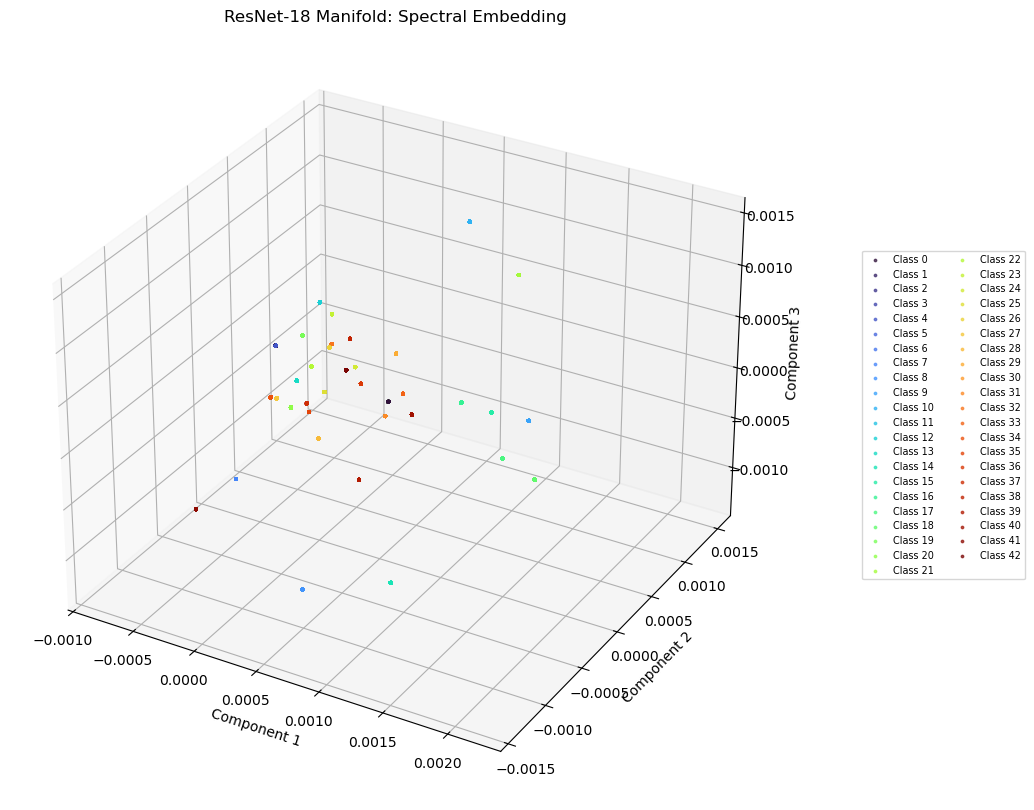

In [40]:
from sklearn.manifold import SpectralEmbedding

SPECTRAL_DIR = "../experiments/embeddings/SPECTRAL/"
SPECTRAL_FILENAME = "se_results.pkl"
pickle_path = os.path.join(SPECTRAL_DIR, SPECTRAL_FILENAME)
os.makedirs(SPECTRAL_DIR, exist_ok=True)

# Since this computation takes a while (made some tests before)
# we are going to check if the file exists, if it already exists, it means
# that those embeddings were already computed and we load them from the mem instead of recompute all!
if os.path.exists(pickle_path):
    print("[WARNING] Spectral Embdeddings already computed, loading them from: {}".format(pickle_path))
    with open(pickle_path, "rb") as f:
        se_results = pickle.load(f)
else:
    print("[WARNING] Spectral Embdeddings computation started {}".format(pickle_path))
    print("Embeddings shape: {}".format(ft_embeddings.shape))
    ft_scaled = normalize_embeddings(ft_embeddings)
    spectral_embeddings = SpectralEmbedding(n_components=3, affinity='nearest_neighbors', n_neighbors=100, eigen_solver='arpack', random_state=99)
    se_results = spectral_embeddings.fit_transform(ft_scaled)
    # saving them
    with open(pickle_path, 'wb') as f:
        pickle.dump(se_results, f)
    print("Spectral Embeddings saved at: {}".format(pickle_path))

plot_embeddings(embeddings=se_results, labels=ft_labels, title="ResNet-18 Manifold: Spectral Embedding", save_path=os.path.join(SPECTRAL_DIR, "spectral_manifold_threedim.png"))
plot_embeddings(embeddings=se_results, labels=ft_labels, title="ResNet-18 Manifold: Spectral Embedding", type="plotly")

In [41]:
# did we plotted everything?
print(len(se_results))

26640


### Try it!
Here you pass to the function a class from 0 to 42 and see the results of the manifold using DM.

You chose: 1
Class cardinality of: 1 = 1500


/var/folders/by/s5tsgrlj5ws2sv5xjl7yqppr0000gn/T/ipykernel_16429/1527084006.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels_np = np.array(ft_labels).flatten()


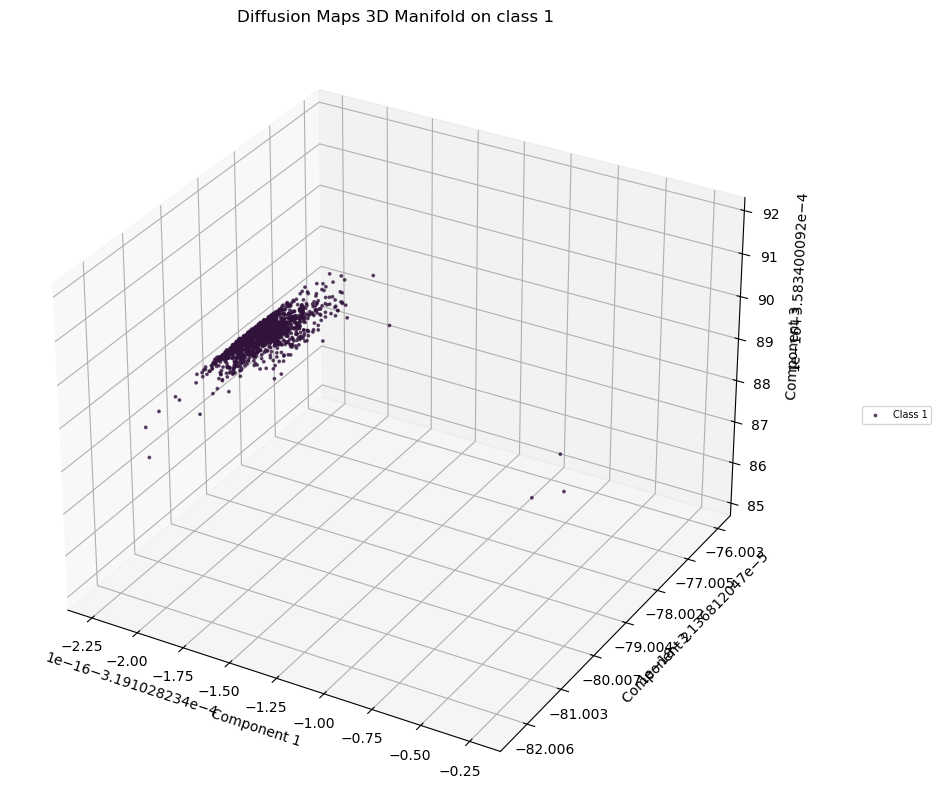

In [42]:
def plot_class_focus(embeddings, target_label):
    labels_np = np.array(ft_labels).flatten()
    embeddings_np = np.array(embeddings)
    mask = labels_np == target_label
    filtered_embeddings = embeddings_np[mask]
    filtered_labels = labels_np[mask]
    print("Class cardinality of: {} = {}".format(target_label, len(filtered_embeddings)))
    if len(filtered_embeddings) > 0:
        plot_embeddings(embeddings=filtered_embeddings, labels=filtered_labels, title="Diffusion Maps 3D Manifold on class {}".format(target_label))

TARGET_CLASS = int(input("Choose a class from 0 to 42"))
print("You chose: {}".format(TARGET_CLASS))

plot_class_focus(se_results, TARGET_CLASS)

#### Results
**Analysis:**<br>
At first glance, the results didn’t look very promising.<br>
It seemed that not even all points obtained using **Diffusion Maps** were plotted, actually what happens is that (in the majority of the cases), clusters are so well separated that (looking everything together) they seems single points, while actually they are cluster with a very low intra-cluster sparsity.<br>
<br>
Despite PCA proved that the model did a good job in separating the classes using only linear relationships, <br>
DM confirmed this point of view by considering also non-linear relationships.<br>
This kind of non-linear relationships, if taken into account, shows that the clusters have been very easily separated by the model!<br>
(I probably should have considered non-linear DM manifold first and then linear PCA manifold, but when I did PCA, I hadn’t yet read the metioned paper).

# Just for completeness
## After the ResNet fine tuning with MLP it would have been interesting to take a look at the new manifolds

In [43]:
ft_resnet_mlp = load_model(model_path="../experiments/MLP_WANDB/EP15_LR0.001_BS128/ep15_lr0.001_bs128_last_model.pth")
ft_resnet_mlp

Model loaded!


/var/folders/by/s5tsgrlj5ws2sv5xjl7yqppr0000gn/T/ipykernel_16429/2757040178.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_weights = torch.load(model_path)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [44]:
ft_mlp_embeddings, ft_mlp_labels = encode_inputs(ft_resnet_mlp, train_loader, "../experiments/embeddings/MLP", "GTSRB Embeddings obtained using ResNet18+MLP (first two freezed)")
print("Embeddings shape: {}".format(ft_mlp_embeddings.shape))
print("Labels shape: {}".format(ft_mlp_labels.shape))

Embeddings shape: torch.Size([26640, 512])
Labels shape: torch.Size([26640, 1])


### No embeddings normalization

In [45]:
mlp_embeddings_threedim = run_pca(ft_mlp_embeddings, num_components=3) # PCA on 512-dim embeddings with normalization
mlp_embeddings_threedim

Principal Component Analysis over 3 components and normalization = False


array([[-7.8417444 ,  0.1804018 , -4.714942  ],
       [-7.755779  ,  0.85197544, -4.9777694 ],
       [-9.088556  ,  0.38480186, -4.8769755 ],
       ...,
       [ 1.434102  , -8.425032  ,  5.237166  ],
       [-2.056219  , -8.613201  ,  3.4495876 ],
       [ 1.6336393 , -8.886482  ,  5.159675  ]],
      shape=(26640, 3), dtype=float32)

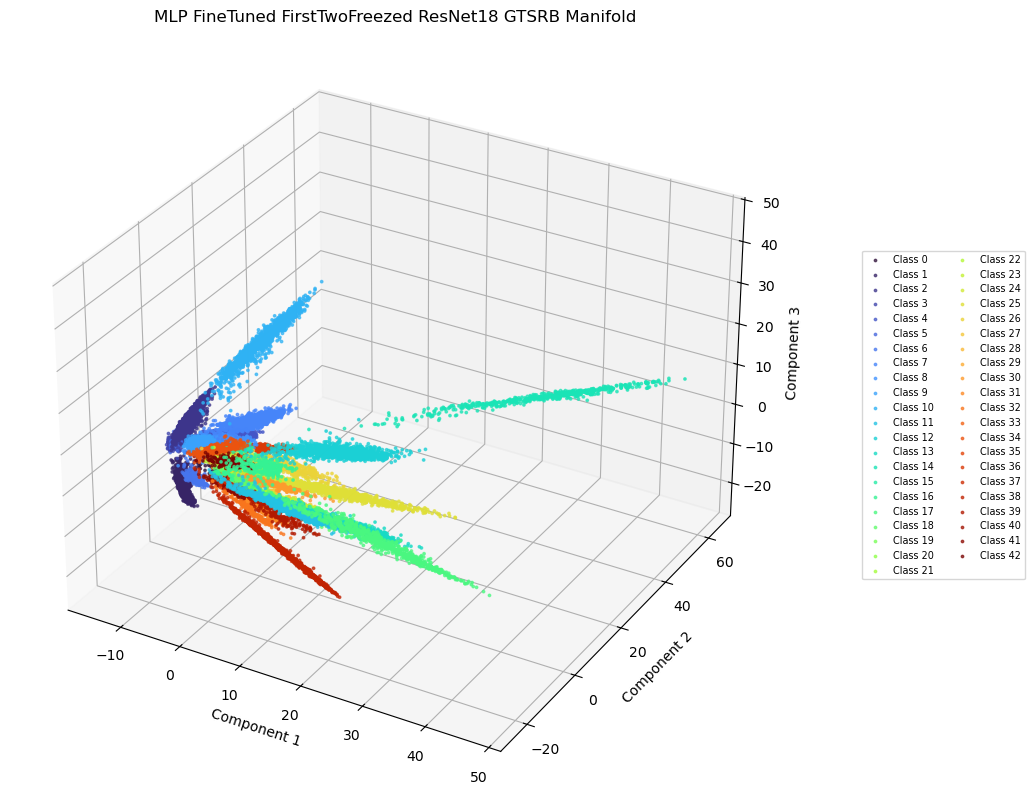

In [46]:
plot_embeddings(mlp_embeddings_threedim, ft_mlp_labels, "MLP FineTuned FirstTwoFreezed ResNet18 GTSRB Manifold", save_path="../experiments/embeddings/MLP/mlp_resnet.png", type="matplotlib")

### With embeddings normalization

In [47]:
mlp_embeddings_threedim_norm = run_pca(ft_mlp_embeddings, num_components=3, to_normalize = True) # PCA on 512-dim embeddings with normalization
mlp_embeddings_threedim_norm

Principal Component Analysis over 3 components and normalization = True


array([[-0.11622655, -0.29350913, -0.10118023],
       [-0.12080635, -0.30780762, -0.12708877],
       [-0.1601902 , -0.33280364, -0.07168363],
       ...,
       [ 0.08688439,  0.17122695,  0.20436953],
       [ 0.08351547,  0.16547866,  0.2207078 ],
       [ 0.09656215,  0.16627412,  0.21040052]],
      shape=(26640, 3), dtype=float32)

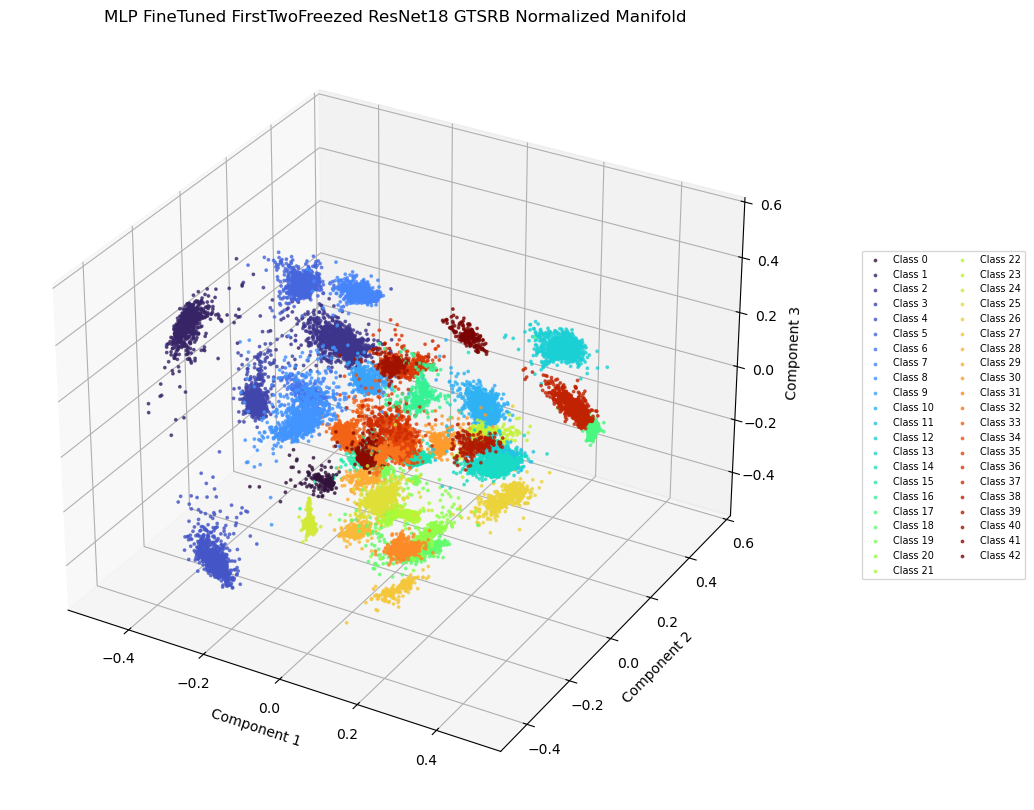

In [48]:
plot_embeddings(mlp_embeddings_threedim_norm, ft_mlp_labels, "MLP FineTuned FirstTwoFreezed ResNet18 GTSRB Normalized Manifold", save_path="../experiments/embeddings/MLP/normalized_mlp_resnet.png", type="matplotlib")

In [49]:
plot_embeddings(mlp_embeddings_threedim_norm, ft_mlp_labels, "MLP FineTuned FirstTwoFreezed ResNet18 GTSRB Normalized Manifold", type="plotly")

In [50]:
mlp_clusters_sc = compute_silhouette_score(ft_mlp_embeddings, ft_mlp_labels, to_normalize=True)
print("Silhouette's Coefficent using MLP FineTuned ResNet18 embeddings (normalized): {}".format(mlp_clusters_sc))

/Users/edoardocanti/opt/anaconda3/envs/DLA2026/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Silhouette's Coefficent using MLP FineTuned ResNet18 embeddings (normalized): 0.8208039999008179


#### Results
**Analysis:**<br>
Reminder: **MLP has been trained on half of the epochs of Linear layer.**
Despite MLP was trained on half of the epochs of Linear layer, the accuracy on test set are almost the same, this fact indicate the ability of this model to learn more efficiently representations (seems fair enough...)<br>
<br>
Also the, **Silhouette Coefficient** is lower (MLP: 0.82 vs LINEAR: 0.87)
<br>
<br>
A personal thought (should be verified):<br>
  I would expect in general better performances from MLP wrt Linear, but I'm not sure if the Silhouette's coeff could be improved that much, due to the fact that, while the Linear layer is forced to linearly separate the space (and by so grouping closely equally-labeled data); the MLP would use non linear transformations, that (potentially) could not require compactness between equally-labeled data.